c:\Users\DIMPLE MUNDHRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 - 9s - 6ms/step - accuracy: 0.4759 - loss: 1.4597
Epoch 2/10
1563/1563 - 7s - 5ms/step - accuracy: 0.6046 - loss: 1.1246
Epoch 3/10
1563/1563 - 7s - 5ms/step - accuracy: 0.6541 - loss: 0.9891
Epoch 4/10
1563/1563 - 7s - 5ms/step - accuracy: 0.6834 - loss: 0.9056
Epoch 5/10
1563/1563 - 7s - 5ms/step - accuracy: 0.7073 - loss: 0.8403
Epoch 6/10
1563/1563 - 7s - 5ms/step - accuracy: 0.7290 - loss: 0.7813
Epoch 7/10
1563/1563 - 7s - 5ms/step - accuracy: 0.7429 - loss: 0.7288
Epoch 8/10
1563/1563 - 8s - 5ms/step - accuracy: 0.7630 - loss: 0.6819
Epoch 9/10
1563/1563 - 8s - 5ms/step - accuracy: 0.7749 - loss: 0.6362
Epoch 10/10
1563/1563 - 8s - 5ms/step - accuracy: 0.7905 - loss: 0.5964
313/313 - 1s - 3ms/step - accuracy: 0.6904 - loss: 0.9507
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


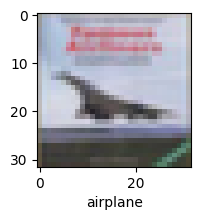

Actual Class: airplane
Predicted Class: airplane


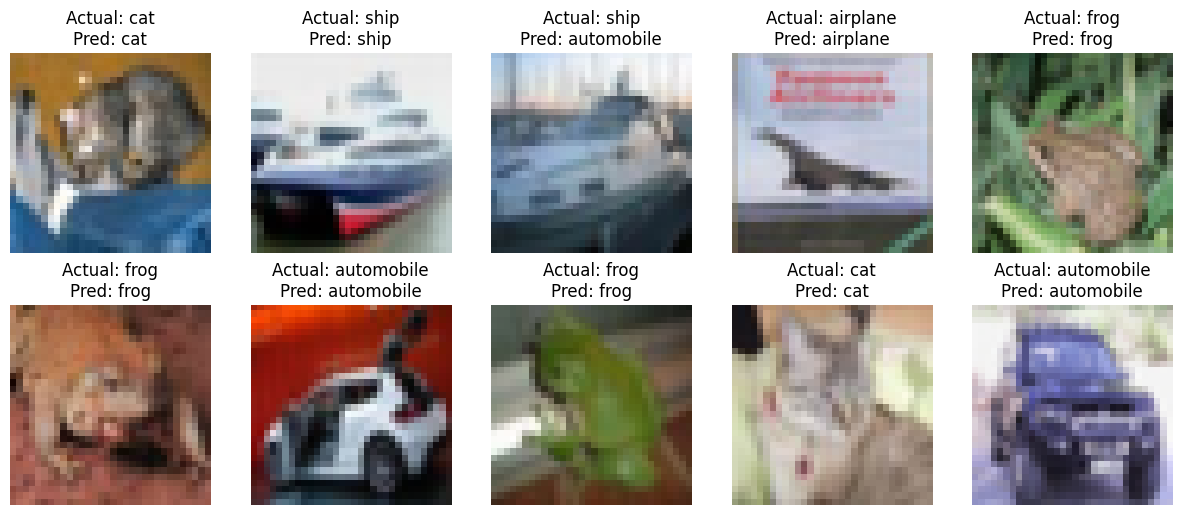

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix , classification_report

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Flatten labels
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Define class names
classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

# Function to plot image samples
def plot_sample(X, y, index):
    plt.figure(figsize=(2,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
    plt.show()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN model
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Train CNN
cnn.fit(X_train, y_train, epochs=10, verbose=2)

# Evaluate CNN
cnn.evaluate(X_test,y_test, verbose=2)

# CNN predictions
y_pred = cnn.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

# Show actual vs predicted for index 3
plot_sample(X_test, y_test, 3)
print("Actual Class:", classes[y_test[3]])
print("Predicted Class:", classes[y_pred_classes[3]])

# Show first 10 test images with predictions
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    plt.title(f"Actual: {classes[y_test[i]]}\nPred: {classes[y_pred_classes[i]]}")
    plt.axis("off")
plt.show()
